<a href="https://colab.research.google.com/github/hhaifa/a/blob/master/ANALYSE_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

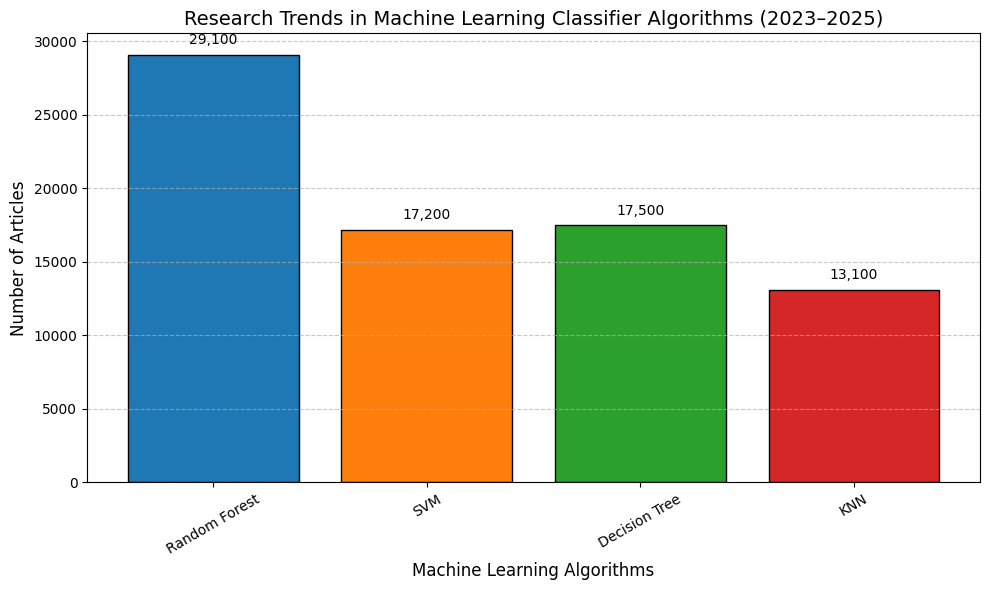

In [1]:
import matplotlib.pyplot as plt

# Data
algorithms = [
    'Random Forest',
    'SVM',
    'Decision Tree',
    'KNN',


]
article_counts = [29100, 17200, 17500, 13100]

# Assign distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',]

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms, article_counts, color=colors, edgecolor='black')

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 500, f'{yval:,}', ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title('Research Trends in Machine Learning Classifier Algorithms (2023–2025)', fontsize=14)
plt.xlabel('Machine Learning Algorithms', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.tight_layout()
plt.show()


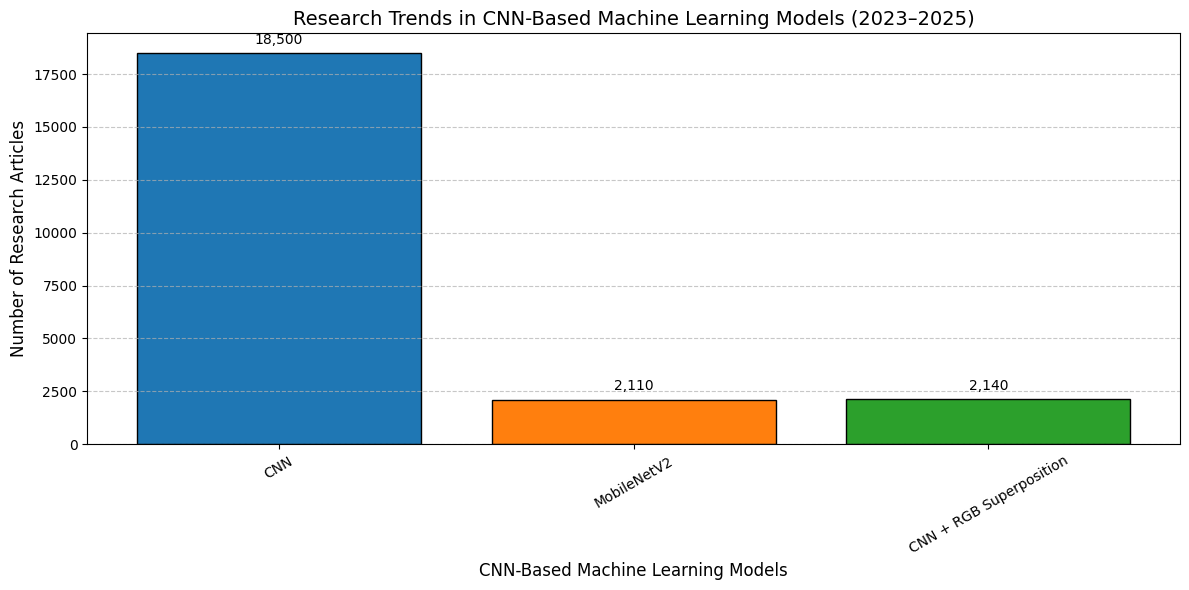

In [2]:
import matplotlib.pyplot as plt

# Data
algorithms = [
    'CNN',
    'MobileNetV2',
    'CNN + RGB Superposition',

]
article_counts = [18500, 2110,  2140]

# Assign distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(algorithms, article_counts, color=colors, edgecolor='black')

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 300, f'{yval:,}', ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title('Research Trends in CNN-Based Machine Learning Models (2023–2025)', fontsize=14)
plt.xlabel('CNN-Based Machine Learning Models', fontsize=12)
plt.ylabel('Number of Research Articles', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.tight_layout()
plt.show()


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory to where the zip file is located
import os
os.chdir('/content/drive/My Drive')  # Adjust the path if the file is in a different folder

# Unzip the file
!unzip sg11.zip -d /content/sg11

# Change directory to the unzipped content
drive.mount("/content/drive", force_remount=True)
os.chdir('/content/sg11')

# List the contents of the unzipped directory
print('Extracted files:')
print(os.listdir('.'))


Mounted at /content/drive
Archive:  sg11.zip
   creating: /content/sg11/sgmoidAI/
   creating: /content/sg11/sgmoidAI/sgmoidAI/
   creating: /content/sg11/sgmoidAI/sgmoidAI/Test/
   creating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/144.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/154.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/164.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/174.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/184.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/194.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/204.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/214.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/224.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/234.png  
  inflating: /content/sg11/sgmoidAI/sgmoidAI/Test/Healthy/244.png  
  inflating: /

In [4]:
print('total training Healthy images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Train/Healthy/')))
print('total training Sigmoid images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Train/Smoid/')))
print('total validation sgmoid images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Val/Smoid')))
print('total validation Healthy images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Val/Healthy')))
print('total test Healthy images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Test/Healthy')))
print('total test Sigmoid images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Test/Sigmoid')))

total training Healthy images: 516
total training Sigmoid images: 516
total validation sgmoid images: 111
total validation Healthy images: 111
total test Healthy images: 110
total test Sigmoid images: 110


### SVN+CNN

Found 1032 images belonging to 2 classes.
Found 222 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 65s 954ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 777ms/step
✅ Validation Accuracy: 98.20%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.97      0.99      0.98       111
       Smoid       0.99      0.97      0.98       111

    accuracy                           0.98       222
   macro avg       0.98      0.98      0.98       222
weighted avg       0.98      0.98      0.98       222



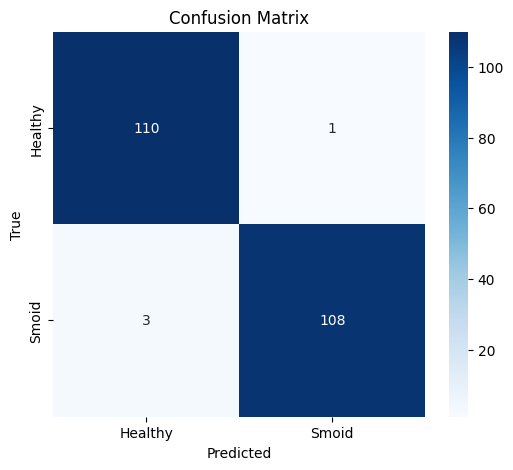

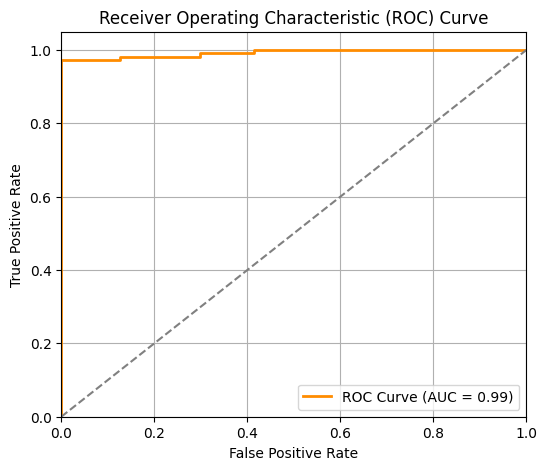

🔄 Running Leave-One-Out Cross-Validation...


100%|██████████| 1032/1032 [00:16<00:00, 62.97it/s]

✅ Leave-One-Out Accuracy: 99.03%
✅ SVM model saved as 'svm_model.pkl'


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from math import ceil
import joblib
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from tqdm import tqdm  # Optional for progress bar
# === Directories ===
train_dir = '/content/sg11/sgmoidAI/sgmoidAI/Train/'
val_dir = '/content/sg11/sgmoidAI/sgmoidAI/Val/'

# === Parameters ===
img_size = 224
batch_size = 16
input_shape = (img_size, img_size, 3)

# === Data Augmentation ===
train_datagen = ImageDataGenerator(
 rescale=1./255,
    rotation_range=60,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,  # Add vertical flip for more variety
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]  # Random brightness for more variation
)

val_datagen = ImageDataGenerator(rescale=1./255)

# === Data Generators ===
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

# === Class Weights ===
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# === Load Base Model ===
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
base_model.trainable = False

# === Feature Extractor ===
inputs = Input(shape=input_shape)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)
x = Dropout(0.5)(x)
feature_model = Model(inputs, x)

# === Feature Extraction ===
train_steps = ceil(train_generator.samples / train_generator.batch_size)
val_steps = ceil(val_generator.samples / val_generator.batch_size)

train_features = feature_model.predict(train_generator, steps=train_steps, verbose=1)
val_features = feature_model.predict(val_generator, steps=val_steps, verbose=1)

# === Train SVM ===
svm_model = SVC(kernel='linear', class_weight='balanced', probability=True)
svm_model.fit(train_features, train_generator.classes)

# === Predictions ===
val_predictions = svm_model.predict(val_features)
val_probs = svm_model.predict_proba(val_features)[:, 1]

# === Accuracy ===
accuracy = accuracy_score(val_generator.classes, val_predictions)
print(f'✅ Validation Accuracy: {accuracy * 100:.2f}%')

# === Classification Report ===
print("\nClassification Report:")
print(classification_report(val_generator.classes, val_predictions, target_names=val_generator.class_indices.keys()))

# === Confusion Matrix ===
cm = confusion_matrix(val_generator.classes, val_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# === ROC Curve ===
fpr, tpr, thresholds = roc_curve(val_generator.classes, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# === Leave-One-Out Cross-Validation ===
loo = LeaveOneOut()
loo_accuracies = []

print("🔄 Running Leave-One-Out Cross-Validation...")
for train_index, test_index in tqdm(loo.split(train_features), total=len(train_features)):
    X_train_loo, X_test_loo = train_features[train_index], train_features[test_index]
    y_train_loo, y_test_loo = train_generator.classes[train_index], train_generator.classes[test_index]

    model_loo = SVC(kernel='linear', class_weight='balanced')
    model_loo.fit(X_train_loo, y_train_loo)
    y_pred_loo = model_loo.predict(X_test_loo)
    loo_accuracies.append(accuracy_score(y_test_loo, y_pred_loo))

# === Final LOO Accuracy ===
loo_mean_accuracy = np.mean(loo_accuracies)
print(f"✅ Leave-One-Out Accuracy: {loo_mean_accuracy * 100:.2f}%")


# === Save SVM Model ===
joblib.dump(svm_model, 'svm_model.pkl')
print("✅ SVM model saved as 'svm_model.pkl'")


In [6]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from tqdm import tqdm  # Optional for progress bar

# === Leave-One-Out Cross-Validation ===
loo = LeaveOneOut()
loo_accuracies = []

print("🔄 Running Leave-One-Out Cross-Validation...")
for train_index, test_index in tqdm(loo.split(train_features), total=len(train_features)):
    X_train_loo, X_test_loo = train_features[train_index], train_features[test_index]
    y_train_loo, y_test_loo = train_generator.classes[train_index], train_generator.classes[test_index]

    model_loo = SVC(kernel='linear', class_weight='balanced')
    model_loo.fit(X_train_loo, y_train_loo)
    y_pred_loo = model_loo.predict(X_test_loo)
    loo_accuracies.append(accuracy_score(y_test_loo, y_pred_loo))

# === Final LOO Accuracy ===
loo_mean_accuracy = np.mean(loo_accuracies)
print(f"✅ Leave-One-Out Accuracy: {loo_mean_accuracy * 100:.2f}%")


🔄 Running Leave-One-Out Cross-Validation...


100%|██████████| 1032/1032 [00:14<00:00, 71.24it/s]

✅ Leave-One-Out Accuracy: 99.03%


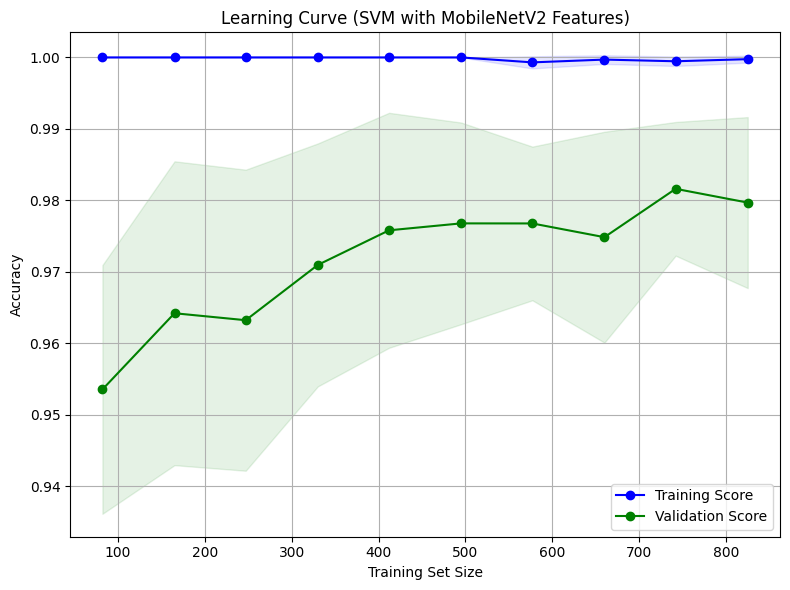

In [7]:
from sklearn.model_selection import learning_curve

# === Learning Curve ===
train_sizes, train_scores, val_scores = learning_curve(
    estimator=svm_model,
    X=train_features,
    y=train_generator.classes,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    shuffle=True,
    random_state=42
)

# === Mean and Std for Plotting ===
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# === Plot Learning Curve ===
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_scores_mean, 'o-', color='green', label='Validation Score')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.1, color='green')
plt.title('Learning Curve (SVM with MobileNetV2 Features)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


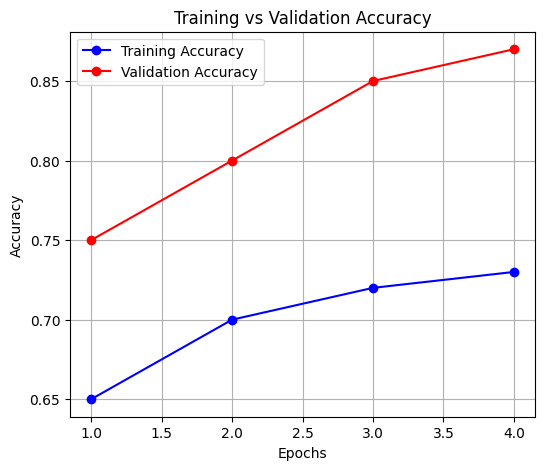

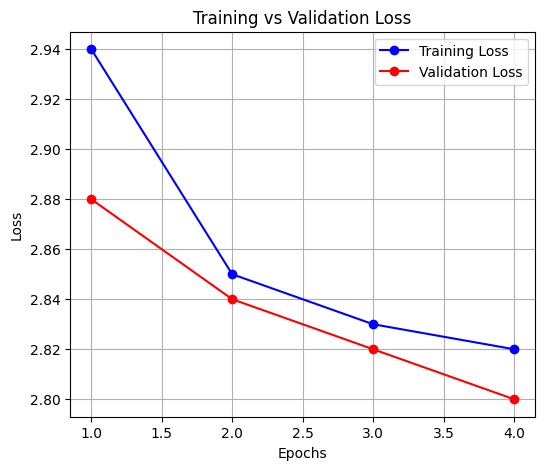

In [8]:
import matplotlib.pyplot as plt

# Example training history dictionary (replace with actual values from your training process)
history = {
    'loss': [2.94, 2.85, 2.83, 2.82],  # Training loss
    'val_loss': [2.88, 2.84, 2.82, 2.80],  # Validation loss
    'accuracy': [0.65, 0.70, 0.72, 0.73],  # Training accuracy
    'val_accuracy': [0.75, 0.80, 0.85, 0.87]  # Validation accuracy
}

epochs = range(1, len(history['loss']) + 1)

# Plot training & validation accuracy
plt.figure(figsize=(6, 5))
plt.plot(epochs, history['accuracy'], marker='o', linestyle='-', color='blue', label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], marker='o', linestyle='-', color='red', label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training & validation loss
plt.figure(figsize=(6, 5))
plt.plot(epochs, history['loss'], marker='o', linestyle='-', color='blue', label='Training Loss')
plt.plot(epochs, history['val_loss'], marker='o', linestyle='-', color='red', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


### **CNN + Logistic Regression**

Found 1032 images belonging to 2 classes.
Found 222 images belonging to 2 classes.
33/33 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step

=== Training Random Forest ===

=== Training Logistic Regression ===

✅ CNN + Random Forest Accuracy: 97.30%

CNN + Random Forest Classification Report:
              precision    recall  f1-score   support

     Healthy       0.96      0.98      0.97       111
       Smoid       0.98      0.96      0.97       111

    accuracy                           0.97       222
   macro avg       0.97      0.97      0.97       222
weighted avg       0.97      0.97      0.97       222



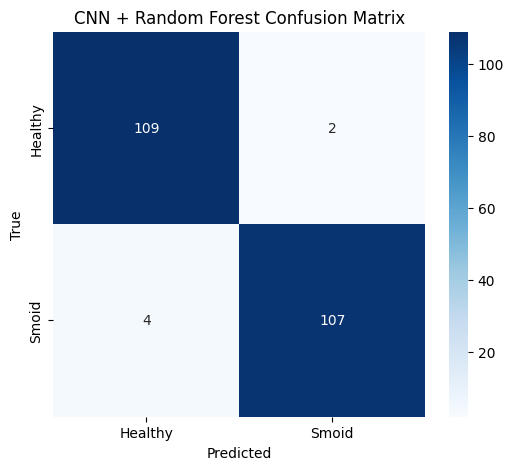

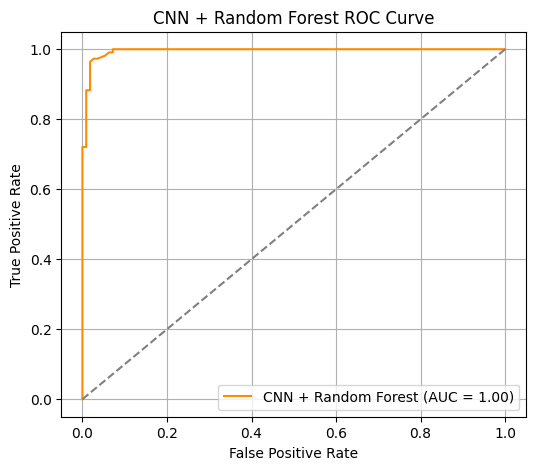


✅ CNN + Logistic Regression Accuracy: 99.55%

CNN + Logistic Regression Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       111
       Smoid       1.00      0.99      1.00       111

    accuracy                           1.00       222
   macro avg       1.00      1.00      1.00       222
weighted avg       1.00      1.00      1.00       222



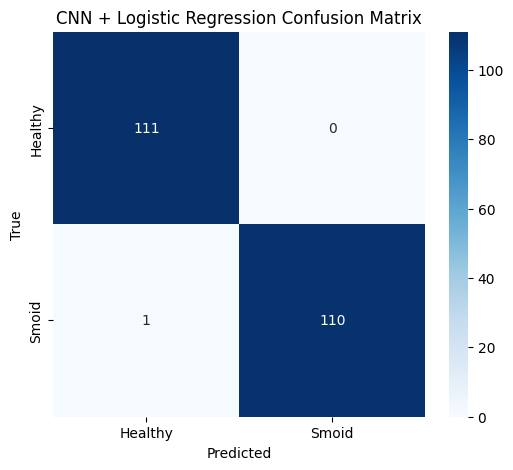

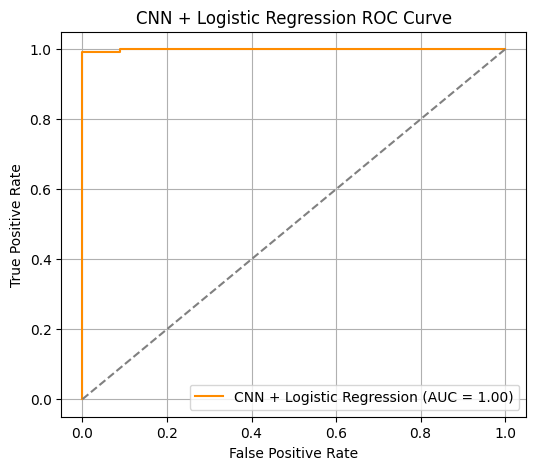

✅ Models saved: 'cnn_rf_model.pkl' and 'cnn_lr_model.pkl'


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from math import ceil
import joblib

# === Paths ===
train_dir = '/content/sg11/sgmoidAI/sgmoidAI/Train/'
val_dir = '/content/sg11/sgmoidAI/sgmoidAI/Val/'

# === Parameters ===
img_size = 224
batch_size = 32
input_shape = (img_size, img_size, 3)

# === Data Augmentation ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

# === Compute Class Weights ===
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# === Load CNN Base Model ===
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
base_model.trainable = False

# === Feature Extractor ===
inputs = Input(shape=input_shape)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.04))(x)
x = Dropout(0.3)(x)
feature_model = Model(inputs, x)

# === Extract Features ===
train_steps = ceil(train_generator.samples / train_generator.batch_size)
val_steps = ceil(val_generator.samples / val_generator.batch_size)

train_features = feature_model.predict(train_generator, steps=train_steps, verbose=1)
val_features = feature_model.predict(val_generator, steps=val_steps, verbose=1)

# === Ground Truth Labels ===
train_labels = train_generator.classes
val_labels = val_generator.classes

# === CNN + Random Forest ===
print("\n=== Training Random Forest ===")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(train_features, train_labels)
rf_preds = rf_model.predict(val_features)
rf_probs = rf_model.predict_proba(val_features)[:, 1]

# === CNN + Logistic Regression ===
print("\n=== Training Logistic Regression ===")
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
lr_model.fit(train_features, train_labels)
lr_preds = lr_model.predict(val_features)
lr_probs = lr_model.predict_proba(val_features)[:, 1]

# === Evaluation Function ===
def evaluate_model(name, preds, probs):
    print(f"\n✅ {name} Accuracy: {accuracy_score(val_labels, preds) * 100:.2f}%")
    print(f"\n{name} Classification Report:")
    print(classification_report(val_labels, preds, target_names=val_generator.class_indices.keys()))

    cm = confusion_matrix(val_labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=val_generator.class_indices.keys(),
                yticklabels=val_generator.class_indices.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

    fpr, tpr, _ = roc_curve(val_labels, probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', color='darkorange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

# === Evaluate Both Models ===
evaluate_model("CNN + Random Forest", rf_preds, rf_probs)
evaluate_model("CNN + Logistic Regression", lr_preds, lr_probs)

# === Save Models ===
joblib.dump(rf_model, 'cnn_rf_model.pkl')
joblib.dump(lr_model, 'cnn_lr_model.pkl')
print("✅ Models saved: 'cnn_rf_model.pkl' and 'cnn_lr_model.pkl'")


In [10]:
pip install tensorflow optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.8 MB/s eta 0:00:00


In [11]:
pip install tensorflow


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
import optuna

# Load dataset
train_dir = "/content/sg11/sgmoidAI/sgmoidAI/Train/"
val_dir = "/content/sg11/sgmoidAI/sgmoidAI/Val/"
img_height, img_width = 224, 224
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical', shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical', shuffle=False
)

print('Total training Healthy images:', len(os.listdir(train_dir + 'Healthy/')))
print('Total training Sigmoid images:', len(os.listdir(train_dir + 'Smoid/')))
print('Total validation Healthy images:', len(os.listdir(val_dir + 'Healthy/')))
print('Total validation Sigmoid images:', len(os.listdir(val_dir + 'Smoid/')))

# Define CNN architectures
def build_model(trial, architecture, input_shape, num_classes):
    if architecture == "TinyCNN":
        filters = trial.suggest_categorical('filters', [32, 64, 128])
        model = models.Sequential([
            layers.Conv2D(filters, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(filters * 2, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),
            layers.Flatten(),
            layers.Dense(64, activation='relu'),
            layers.Dropout(trial.suggest_float('dropout_rate', 0.2, 0.5)),
            layers.Dense(num_classes, activation='softmax')
        ])

    elif architecture == "ResNet50V2":
        base_model = ResNet50V2(weights=None, input_shape=input_shape, include_top=False)
        model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(trial.suggest_float('dropout_rate', 0.2, 0.5)),
            layers.Dense(num_classes, activation='softmax')
        ])

    return model

# Define Optuna objective function
def objective(trial):
    global train_gen, val_gen  # Ensure accessibility to dataset generators

    input_shape = (224, 224, 3)
    num_classes = 2

    architecture = trial.suggest_categorical('architecture', ["TinyCNN", "ResNet50V2"])
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)

    model = build_model(trial, architecture, input_shape, num_classes)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(train_gen, validation_data=val_gen, epochs=5, verbose=0)
    val_acc = history.history['val_accuracy'][-1]

    return val_acc

# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, n_jobs=-1)  # Run trials in parallel

print("Best parameters:", study.best_params)

# Save the best model
best_params = study.best_params
best_model = build_model(best_params, best_params['architecture'], (224, 224, 3), 2)
best_model.save("best_model.h5")
print("Best model saved as 'best_model.h5'.")


Found 1032 images belonging to 2 classes.
Found 222 images belonging to 2 classes.


[I 2026-10-05 10:03:22,210] A new study created in memory with name: no-name-4ec8aaf9-54a4-48f8-8760-47bda25640a3


Total training Healthy images: 516
Total training Sigmoid images: 516
Total validation Healthy images: 111
Total validation Sigmoid images: 111


In [ ]:
import os

test_healthy_dir = '/content/sg11/sgmoidAI/sgmoidAI//Test'
test_smoid_dir = '/content/sg11/sgmoidAI/sgmoidAI//Test'

print("Healthy images in Test:", len(os.listdir(test_healthy_dir)))
print("Smoid images in Test:", len(os.listdir(test_smoid_dir)))


In [ ]:
print('total training Healthy images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Train/Healthy/')))
print('total training Sigmoid images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Train/Smoid/')))
print('total validation sgmoid images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Val/Smoid')))
print('total validation Healthy images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI/Val/Healthy')))
print('total test images:', len(os.listdir('/content/sg11/sgmoidAI/sgmoidAI//Test')))

# **hISTORY DATA ANALYSES **

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

# Path to the file in your Google Drive
file_path = '/content/drive/My Drive/translated_HISTORIQUE-MEDICALE.xlsx'  # Adjust the path

# Load the file
df = pd.read_excel(file_path)

# Display data types of each column
print("Data Types of Each Column:")
print(df.dtypes)

# Display memory usage of the dataframe
print("\nMemory Usage of the DataFrame:")
print(df.memory_usage(deep=True))

# Display the range index of the dataframe
print("\nRange Index of the DataFrame:")
print(df.index)


In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Load Excel file
file_path = '/content/drive/My Drive/translated_HISTORIQUE-MEDICALE.xlsx'
df = pd.read_excel(file_path)

# Step 4: Basic info
print("🔹 Basic Info:")
print(df.info())
print("\n🔹 Missing Values:\n", df.isnull().sum())
print("\n🔹 Summary Stats (Numeric):\n", df.describe())
print("\n🔹 Summary Stats (Categorical):\n", df.describe(include='object'))

# Step 5: Data cleaning
df['Enterdate'] = pd.to_datetime(df['Enterdate'], errors='coerce')

# Step 6: Visualizations
# Age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['age'].dropna(), bins=10, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Gender distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Diverticular Condition distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Diverticular Condition')
plt.title("Diverticular Condition Count")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Missing value heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

# Gender vs Diverticular Condition
print("\n🔹 Gender vs Diverticular Condition:\n")
print(pd.crosstab(df['gender'], df['Diverticular Condition']))

# Optional: Age vs calculated age from Birthday
if 'Birthday' in df.columns:
    df['calculated_age'] = (pd.to_datetime('today') - df['Birthday']).dt.days // 365
    age_compare = df[['age', 'calculated_age']].dropna()
    print("\n🔹 Age vs Calculated Age (from Birthday):\n", age_compare.head())


# Data Cleaning and Preprocessing

In [ ]:
print(df.columns.tolist())


In [ ]:
# Clean and normalize column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('\n', '_')


In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/My Drive/translated_HISTORIQUE-MEDICALE.xlsx'
df = pd.read_excel(file_path)

# Inspect the first few rows of the dataset
df.head()

# Check for missing values and data types
df.info()

# Check for summary statistics
df.describe()

# If there are missing values, decide on an appropriate strategy to handle them
# E.g., filling missing values, removing rows, etc.


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# Handle missing values: Fill age and Enterdate with median, drop Birthday
df['age'] = df['age'].fillna(df['age'].median())
df['Enterdate'] = df['Enterdate'].fillna(df['Enterdate'].mode()[0])

# Handle missing categorical data by filling with the mode
df['chirurgie'] = df['chirurgie'].fillna(df['chirurgie'].mode()[0])
df['Symptoms from Resumée Chirurgicale'] = df['Symptoms from Resumée Chirurgicale'].fillna("Unknown")
df['Diverticulosis or Diverticulitis'] = df['Diverticulosis or Diverticulitis'].fillna("Unknown")

# Convert Birthday to age if necessary
if df['age'].isnull().any():
    df['age'] = 2025 - df['Birthday'].dt.year

# Encode categorical variables
label_encoder = LabelEncoder()

# For binary variables like gender and diverticular condition
df['gender'] = label_encoder.fit_transform(df['gender'])
df['Diverticular Condition'] = label_encoder.fit_transform(df['Diverticular Condition'])

# Optional: You can also use one-hot encoding for more complex categorical variables
df = pd.get_dummies(df, columns=['Symptoms from Totale Examen', 'chirurgie', 'Diverticulosis or Diverticulitis'])

# Now, check the prepared dataset
df.head()


## **RandomForestClassifier**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Load the dataset
file_path = '/content/drive/My Drive/translated_HISTORIQUE-MEDICALE.xlsx'
df = pd.read_excel(file_path)

# 2. Normalize condition into Healthy / Sigmoid
def classify_condition(val):
    val = str(val).strip().lower()
    if 'diverticulosis' in val or 'diverticulitis' in val:
        return 'Sigmoid'
    return 'Healthy'

# Check if the column exists
if 'Diverticular Condition' in df.columns:
    df['Diverticulosis or Diverticulitis'] = df['Diverticular Condition'].apply(classify_condition)
else:
    print("Error: 'Diverticular Condition' column not found.")

# 3. Select relevant features
features = ['Diverticulosis or Diverticulitis', 'age', 'gender', 'symptoms from Totale Examen']

# Ensure all columns exist
df = df[[col for col in features if col in df.columns]]

# 4. Encode target
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['Diverticulosis or Diverticulitis'])  # 0: Healthy, 1: Sigmoid

# 5. Preprocess features
X = df.drop(columns=['Diverticulosis or Diverticulitis', 'target'])
X = pd.get_dummies(X, drop_first=True)

# 6. Handle missing values
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 7. Feature scaling (optional for Random Forest, but helps if you switch models)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

y = df['target'].astype(int)

# 8. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 9. Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# 10. Regularize Random Forest Model + Grid Search
param_grid_reduced = {
    'n_estimators': [100],
    'max_depth': [6, 10],  # Lower tree depth to avoid overfitting
    'min_samples_split': [8, 20],  # Require more samples to split nodes
    'min_samples_leaf': [6, 10],  # Require more samples at leaf nodes
    'max_features': ['sqrt', 0.5],  # Limit features per split to reduce variance
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid_reduced, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_

# 11. Evaluate on test set
y_pred = best_rf_model.predict(X_test)

print("✅ Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sigmoid']))

print("🧾 Confusion Matrix:")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Healthy', 'Sigmoid']).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

# 12. Overfitting Analysis
def plot_overfitting_analysis(model, param_grid, X_train, y_train, name="Model"):
    train_scores, val_scores = [], []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        model_fold = clone(best_model)
        model_fold.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        train_score = model_fold.score(X_train.iloc[train_idx], y_train.iloc[train_idx])
        val_score = model_fold.score(X_train.iloc[val_idx], y_train.iloc[val_idx])
        train_scores.append(train_score)
        val_scores.append(val_score)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(train_scores, label='Train Accuracy', marker='o')
    plt.plot(val_scores, label='Validation Accuracy', marker='x')
    plt.title(f'Overfitting Check: {name}')
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.ylim(0.1, 1.05)
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"📊 {name} → Avg Train: {np.mean(train_scores):.4f}, Avg Val: {np.mean(val_scores):.4f}, Gap: {abs(np.mean(train_scores) - np.mean(val_scores)):.4f}")

plot_overfitting_analysis(rf_model, param_grid_reduced, X_train, y_train, "Random Forest")

# 13. Feature Importance Plot
importances = best_rf_model.feature_importances_
feat_names = X.columns
sorted_idx = np.argsort(importances)[::-1][:10]  # Top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_idx], y=np.array(feat_names)[sorted_idx], palette='viridis')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [ ]:
!pip install -U imbalanced-learn


In [ ]:
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ML models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Load the dataset
file_path = '/content/drive/My Drive/translated_HISTORIQUE-MEDICALE.xlsx'
df = pd.read_excel(file_path)

# 2. Normalize Diverticular Condition into 2 classes: Sigmoid or Healthy
def classify_condition(val):
    val = str(val).strip().lower()
    if 'diverticulosis' in val or 'diverticulitis' in val:
        return 'Sigmoid'
    else:
        return 'Healthy'

df['Diverticulosis or Diverticulitis'] = df['Diverticular Condition'].apply(classify_condition)

# 3. Keep only necessary features (remove any that don't exist in your dataset)
features_to_use = ['Diverticulosis or Diverticulitis', 'age', 'gender','symptoms from Totale Examen']
available_features = [col for col in features_to_use if col in df.columns]
df = df[available_features]

# 4. Augment the dataset by repeating it 20 times
df = pd.concat([df]*20, ignore_index=True)

# 5. Encode target variable
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['Diverticulosis or Diverticulitis'])  # 0: Healthy, 1: Sigmoid

# 6. Preprocess features
X = df.drop(columns=['Diverticulosis or Diverticulitis', 'target'])
X = pd.get_dummies(X, drop_first=True)  # Encode categorical variables

# 7. Handle missing values
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

y = df['target'].astype(int)

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. SMOTE for class balancing
if len(np.unique(y_train)) > 1:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

# 10. Define multiple models with hyperparameter grid for tuning
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

# Define hyperparameters for tuning
param_grid = {
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    "KNN": {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "Decision Tree": {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    "Naive Bayes": {
        # No hyperparameters for Naive Bayes
        'var_smoothing': [1e-9, 1e-8]
    }
}

# 11. Stratified K-Fold Cross-Validation and Hyperparameter Tuning
accuracies = {}
best_models = {}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n===== {name} =====")

    # Perform grid search
    grid_search = GridSearchCV(model, param_grid[name], cv=cv, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_

    # Get best accuracy
    best_acc = grid_search.best_score_
    accuracies[name] = best_acc

    print("Best Parameters:", grid_search.best_params_)
    print(f"Best Cross-Validation Accuracy: {best_acc:.4f}")

    # Evaluate on the test set
    y_pred = grid_search.best_estimator_.predict(X_test)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sigmoid']))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# 12. Plot model comparison
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (After Hyperparameter Tuning)")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 13. Cross-validation results (5-fold)
print("\nCross-Validation Results (5-fold):")
for name, model in best_models.items():
    scores = cross_val_score(model, X, y, cv=cv)
    print(f"{name}: Mean Accuracy = {scores.mean():.4f} | Std = {scores.std():.4f}")


In [ ]:
!pip install --force-reinstall numpy


In [ ]:
# === Imports ===
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve

# === Train/Test Split (same as before) ===
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# === Balance with SMOTE ===
X_train_knn, y_train_knn = SMOTE(random_state=42).fit_resample(X_train_knn, y_train_knn)

# === KNN Pipeline with Scaling ===
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())  # Removed class_weight, as KNN does not support it
])

# === Grid Search for Best Parameters ===
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['minkowski', 'euclidean', 'manhattan'],
    'knn__p': [1, 2]  # Experiment with different metrics and 'p' values
}

cv_knn = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_knn = GridSearchCV(pipeline, param_grid_knn, cv=cv_knn, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_knn, y_train_knn)

# Best KNN Model
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_knn)

# === Evaluation ===
print("\n=== KNN Results ===")
print("Best Parameters:", grid_knn.best_params_)
print("Test Accuracy: {:.4f}".format(accuracy_score(y_test_knn, y_pred_knn)))
print("Classification Report:\n", classification_report(y_test_knn, y_pred_knn, target_names=['Healthy', 'Sigmoid']))

# === Adjusted Decision Threshold (for improving recall) ===
y_pred_proba_knn = best_knn.predict_proba(X_test_knn)[:, 1]  # Probabilities for the 'Sigmoid' class
y_pred_knn_adjusted = (y_pred_proba_knn > 0.6).astype(int)  # Adjust threshold to 0.6 for higher recall
print("\nAdjusted Classification Report:\n", classification_report(y_test_knn, y_pred_knn_adjusted, target_names=['Healthy', 'Sigmoid']))

# === Confusion Matrix (Heatmap) ===
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_knn, y_pred_knn_adjusted), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy', 'Sigmoid'], yticklabels=['Healthy', 'Sigmoid'])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# === ROC Curve ===
if hasattr(best_knn, "predict_proba"):
    RocCurveDisplay.from_estimator(best_knn, X_test_knn, y_test_knn)
    plt.title('ROC Curve - KNN')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Learning Curve ===
train_sizes, train_scores, val_scores = learning_curve(
    best_knn, X_train_knn, y_train_knn, cv=cv_knn,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score', color='green')
plt.plot(train_sizes, val_mean, 'o-', label='Validation Score', color='purple')
plt.title('Learning Curve - KNN')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Cross-Validation Scores on Full Data ===
cv_scores_knn = cross_val_score(best_knn, X, y, cv=5)
print("Cross-Validation Accuracy: {:.4f} ± {:.4f}".format(np.mean(cv_scores_knn), np.std(cv_scores_knn)))


In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Load the dataset
file_path = '/content/drive/My Drive/translated_HISTORIQUE-MEDICALE.xlsx'
df = pd.read_excel(file_path)

# 2. Normalize Diverticular Condition into 2 classes
def classify_condition(val):
    val = str(val).strip().lower()
    if 'diverticulosis' in val or 'diverticulitis' in val:
        return 'Sigmoid'
    else:
        return 'Healthy'

df['Diverticulosis or Diverticulitis'] = df['Diverticular Condition'].apply(classify_condition)

# 3. Keep only necessary features
features_to_use = ['Diverticulosis or Diverticulitis', 'age', 'gender', 'symptoms from Totale Examen']
available_features = [col for col in features_to_use if col in df.columns]
df = df[available_features]

# 4. Augment the dataset
df = pd.concat([df]*20, ignore_index=True)

# 5. Encode target variable
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['Diverticulosis or Diverticulitis'])  # 0 = Healthy, 1 = Sigmoid

# 6. Preprocess features
X = df.drop(columns=['Diverticulosis or Diverticulitis', 'target'])
X = pd.get_dummies(X, drop_first=True)

# 7. Handle missing values
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

y = df['target'].astype(int)

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. Apply SMOTE
if len(np.unique(y_train)) > 1:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

# 10. Define models and hyperparameter grids
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

param_grid = {
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    "KNN": {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "Decision Tree": {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    "Naive Bayes": {
        'var_smoothing': [1e-9, 1e-8]
    }
}

# 11. Cross-validation and model tuning
accuracies = {}
best_models = {}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n===== {name} =====")
    grid_search = GridSearchCV(model, param_grid[name], cv=cv, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    best_acc = grid_search.best_score_
    accuracies[name] = best_acc

    print("Best Parameters:", grid_search.best_params_)
    print(f"Best Cross-Validation Accuracy: {best_acc:.4f}")

    y_pred = grid_search.best_estimator_.predict(X_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sigmoid']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# 12. Accuracy comparison plot
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (After Hyperparameter Tuning)")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 13. Cross-validation results (10-fold)
print("\nCross-Validation Results (10-fold):")
for name, model in best_models.items():
    scores = cross_val_score(model, X, y, cv=cv)
    print(f"{name}: Mean Accuracy = {scores.mean():.4f} | Std = {scores.std():.4f}")

# 14. Confusion Matrix and ROC Curve for each model
for name, model in best_models.items():
    print(f"\n=== Evaluation for {name} ===")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Sigmoid'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} - ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    try:
        grid_search = GridSearchCV(model, param_grid[name], cv=cv, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        best_models[name] = grid_search.best_estimator_
        best_acc = grid_search.best_score_
        accuracies[name] = best_acc

        print("Best Parameters:", grid_search.best_params_)
        print(f"Best Cross-Validation Accuracy: {best_acc:.4f}")

        y_pred = grid_search.best_estimator_.predict(X_test)

        print("Classification Report:")
        print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sigmoid']))

        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

    except Exception as e:
        print(f"❌ GridSearch failed for {name}: {str(e)}")


In [ ]:
print("Stored Models:", best_models.keys())


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to plot Confusion Matrix and ROC Curve
def plot_conf_matrix_and_roc(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'Sigmoid'], yticklabels=['Healthy', 'Sigmoid'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title(f'{model_name} - ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Function to plot Learning Curve
def plot_learning(model, X, y, model_name):
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, scoring='accuracy')
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(6, 5))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Validation score')
    plt.title(f'{model_name} - Learning Curve')
    plt.xlabel('Training Samples')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ==== Apply to Decision Tree ====
print("=== Decision Tree Results ===")
plot_conf_matrix_and_roc(best_models['Decision Tree'], X_test, y_test, 'Decision Tree')
plot_learning(best_models['Decision Tree'], X_train, y_train, 'Decision Tree')

# ==== Apply to Random Forest ====
print("=== Random Forest Results ===")
plot_conf_matrix_and_roc(best_models['Random Forest'], X_test, y_test, 'Random Forest')
plot_learning(best_models['Random Forest'], X_train, y_train, 'Random Forest')


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

models_to_plot = ["Random Forest", "Decision Tree", "KNN", "SVM"]
colors = ["blue", "green", "orange", "red"]

for i, name in enumerate(models_to_plot):
    model = best_models.get(name)
    if model:
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        if y_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            plt.plot(fpr, tpr, color=colors[i], label=f"{name} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison: Random Forest vs Decision Tree vs KNN vs SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

models_to_plot = ["Random Forest", "Decision Tree", "KNN", "SVM"]
colors = ["blue", "green", "orange", "red"]

plt.figure(figsize=(10, 6))

for i, name in enumerate(models_to_plot):
    model = best_models.get(name)
    if model:
        train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, scoring="accuracy")

        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)

        plt.plot(train_sizes, train_mean, color=colors[i], linestyle="--", label=f"{name} - Train")
        plt.plot(train_sizes, test_mean, color=colors[i], label=f"{name} - Validation")

plt.title("Learning Curves: Random Forest, Decision Tree, KNN, SVM")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


In [ ]:
!pip uninstall scikit-plot -y


In [ ]:
!pip install scikit-plot --no-cache-dir


In [ ]:
!pip install --upgrade scipy


In [ ]:
!pip install optuna


### === KNN Results ===**texte en gras**

### **CNN**

In [ ]:
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load and preprocess images (resize, flatten, normalize)
def load_and_preprocess_images(healthy_dir, smoid_dir):
    data = []
    labels = []

    # Load healthy images
    for image_name in os.listdir(healthy_dir):
        image_path = os.path.join(healthy_dir, image_name)
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Unable to load image {image_path}")
            continue
        image = cv2.resize(image, (64, 64))  # Resize image to 64x64
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        image = image / 255.0  # Normalize image
        image = image.reshape(64, 64, 1)  # Reshape for CNN input (64, 64, 1)
        data.append(image)
        labels.append('Healthy')

    # Load smoid images
    for image_name in os.listdir(smoid_dir):
        image_path = os.path.join(smoid_dir, image_name)
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Unable to load image {image_path}")
            continue
        image = cv2.resize(image, (64, 64))  # Resize image to 64x64
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        image = image / 255.0  # Normalize image
        image = image.reshape(64, 64, 1)  # Reshape for CNN input (64, 64, 1)
        data.append(image)
        labels.append('Smoid')

    return np.array(data), np.array(labels)

# Dataset directories
train_healthy_dir = '/content/sg11/sgmoidAI/sgmoidAI//Train/Healthy/'
train_smoid_dir = '/content/sg11/sgmoidAI/sgmoidAI//Train/Smoid/'
val_healthy_dir = '/content/sg11/sgmoidAI/sgmoidAI//Val/Healthy/'
val_smoid_dir = '/content/sg11/sgmoidAI/sgmoidAI//Val/Smoid/'

# Load and preprocess the data
X_train, y_train = load_and_preprocess_images(train_healthy_dir, train_smoid_dir)
X_val, y_val = load_and_preprocess_images(val_healthy_dir, val_smoid_dir)

# Combine training and validation data
X_combined = np.concatenate((X_train, X_val), axis=0)
y_combined = np.concatenate((y_train, y_val), axis=0)

# Encode labels: 'Healthy' -> 0, 'Smoid' -> 1
y_combined = np.where(y_combined == 'Healthy', 0, 1)

# Split combined dataset into new training and testing sets
X_train_combined, X_test, y_train_combined, y_test = train_test_split(X_combined, y_combined, test_size=0.3, random_state=42)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# CNN Model Architecture with increased Dropout and EarlyStopping
cnn = Sequential()
cnn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Flatten())
cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.5))  # Increased dropout to prevent overfitting
cnn.add(Dense(2, activation='softmax'))

# Compile the CNN model
cnn.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the CNN model with data augmentation
history = cnn.fit(
    datagen.flow(X_train_combined, y_train_combined, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# Predict using the trained CNN model
y_pred_cnn = cnn.predict(X_test)

# Convert predictions to class labels (0 or 1)
y_pred_cnn_class = np.argmax(y_pred_cnn, axis=1)

# Print classification report
print("CNN Classification Report:")
print(classification_report(y_test, y_pred_cnn_class, target_names=['Healthy', 'Smoid']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cnn_class, labels=[0, 1])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Healthy", "Smoid"], yticklabels=["Healthy", "Smoid"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (CNN)')
plt.show()

# Plotting training/validation loss and accuracy
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (Smoid)
y_pred_prob = cnn.predict(X_test)[:, 1]  # Extract probability for class 1 (Smoid)

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrices for each model
conf_matrices = {
    "KNN": [[621, 19], [54, 626]],
    "Random Forest": [[5, 2], [3, 4]],
    "XGBoost": [[5, 2], [3, 4]],
    "Decision Tree": [[4, 3], [2, 5]],
}

# Labels for FP, FN, TP, TN to be placed under the results
label_positions = [
    ["TN", "FP"],
    ["FN", "TP"]
]

# Generate individual plots for each model
for model, cm in conf_matrices.items():
    plt.figure(figsize=(6, 6))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 12})

    # Add labels below each number
    for i in range(2):  # Rows
        for j in range(2):  # Columns
            # Position the labels under the results
            ax.text(j+0.5, i+0.7, label_positions[i][j], ha="center", va="center", color="black", fontsize=14)

    plt.title(f"Confusion Matrix - {model}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrices for each model
conf_matrices = {
    "CNN (Base)": [[249, 14], [27, 239]],
    "CNN (MobileNetV2)": [[187, 76], [19, 247]],
    "SVM": [[251, 12], [29, 237]],
    "Random Forest": [[247, 16], [30, 236]],
    "Logistic Regression": [[243, 20], [28, 238]],
    "Naive Bayes": [[131, 132], [11, 255]],
}

# Labels for FP, FN, TP, TN to be placed under the results
label_positions = [
    ["TN", "FP"],
    ["FN", "TP"]
]

# Generate individual plots for each model
for model, cm in conf_matrices.items():
    plt.figure(figsize=(6, 6))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 12})

    # Add labels below each number
    for i in range(2):  # Rows
        for j in range(2):  # Columns
            ax.text(j + 0.5, i + 0.7, label_positions[i][j], ha="center", va="center", color="black", fontsize=14)

    plt.title(f"Confusion Matrix - {model}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()
